# SPLSDA: Sparse PLS Discriminant Analysis

Sparse partial least square discriminant analysis or SPLSDA is, as the name suggests, a supervised classification method which is mainly used on datasets which have more of variables or columns than observations or rows. SPLSDA is a modification of partial least square classification where it adds variable selection, so that each component can separates the classes and is defined by only a small subset of the variables.


In this documentation, we will depomstrate implementation of SPLSDA using `BigRiverEssence.splsda` on a `SRBCT` dataset. 


## The method

Let us consider a vector of classes where the $i$th component indicates the class of the $i$th observation. Let $X$ be a matrix of predictors with variables being the columns and observations being the rows. In SPLSDA, the class labels are first
dummy-encoded such that we  get an indicator matrix $Y$ from the vector of classes, where $Y_{ik} = 1$ if sample $i$ belongs
to class $k$. SPLSDA then performs a sparse PLS regression of the predictors $X$ onto this indicator matrix $Y$. 

In SPLSDA, we find each component by obtaining loading vectors $u$ (over variables) and $v$ (over
classes) such that we maximize the covariance between the variable side score $Xu$ and the
class side score $Yv$ using an $L_1$ penalty applied to $u$. Hence the optimization probem can be written as: $$\max_{u,v} \; \operatorname{cov}(Xu, Yv) \quad \text{subject to } \|u\|_2 = \|v\|_2 = 1, \; P_\lambda(u).$$ We apply the $L_1$ penalty using only `keepX` variables for each component. These variables have the largest loadings, the rest are set to $0$. We then solve the component by  alternating soft-thresholded power iteration where we update $u$ from the class scores and threshold it. Then we update $v$ from the variable scores — until the loadings converge. We then deflate the variable block $X$ by regressing on its score. We keep $Y$ untouched. We then extract the next component from the residual, we follow Lê Cao, Boitard & Besse (2011). 

The result gives, per component, a set of `keepX` selected variables (the nonzero loadings) and sample scores that separate the classes.



## The data

We use the `SRBCT` dataset from the `mixOmics` package. It is a gene expression dataset having $63$ sample and $2308$ genes. It also has a set of $4$ tumour classes. The goal is to select a small set of discriminating genes per component that can best discremenate the tumour classes. 

In [ ]:
using BigRiverEssence, RCall, Plots, Statistics
const BRE = BigRiverEssence
gr()

R"""
suppressMessages(library(mixOmics))
data(srbct)
Xg <- srbct$gene
yg <- as.character(srbct$class)
"""
X = rcopy(R"Xg")          # 63 × 2308 gene expression
y = rcopy(R"yg")          # 63 class labels
size(X), unique(y)

((63, 2308), ["EWS", "BL", "NB", "RMS"])

## Fitting the model

Now we fit `splsda` to the predictor matrix $X$. We also pass the number of components we want to have as `ncomp` and the number of variables to have in each of the components as `keepX`. We fit three components, keeping $40$, $9$, and $40$ genes respectively.

In [ ]:
ncomp = 3
keepX = [40, 9, 40]
m = BRE.splsda(X, y, ncomp, keepX)

# confirm the sparsity such that each component keeps exactly keepX genes
[count(!iszero, m.loadings_X[:, c]) for c in 1:m.ncomp]

3-element Vector{Int64}:
 40
  9
 40

The fitted `splsdaStructure` holds the sample scores (`variates_X`), the sparse gene
loadings (`loadings_X`), the class labels, and the dummy encoding.

## Sample plot

Now we project the samples onto the first two components and color by tumor class. This will show us how the discriminant components separate the types.



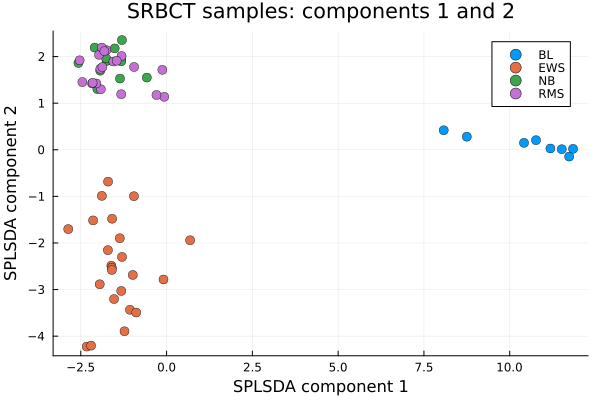

In [16]:
V = m.variates_X
scatter(V[:, 1], V[:, 2]; group = y,
    xlabel = "SPLSDA component 1", ylabel = "SPLSDA component 2",
    title = "SRBCT samples: components 1 and 2", legend = :topright,
    markersize = 5, markerstrokewidth = 0.5)

We note from the above plot that components $1$ and $2$ are able to separate the two of the four tumor types as BL is isolated far
along component $1$, and EWS forms its own cluster along component $2$. The remaining two
classes, NB and RMS, overlap in this plane. They are resolved by the third component, which is why the model was fit with three. It is interesting to see that using only a few dozen genes per component the discriminant directions were able to  pull the tumor types apart.

To see the third component resolve NB and RMS, we plot components $1$ and $3$.



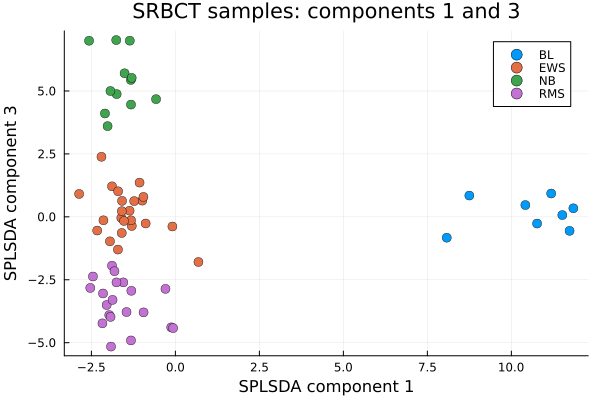

In [13]:
scatter(V[:, 1], V[:, 3]; group = y,
    xlabel = "SPLSDA component 1", ylabel = "SPLSDA component 3",
    title = "SRBCT samples: components 1 and 3", legend = :topright,
    markersize = 5, markerstrokewidth = 0.5)

## Selected genes

As noted before, in SPLSDA, the loadings of each components are sparse as only `keepX` genes are nonzero. Plotting those
nonzero loadings can show us which genes define a component and with what `weight.s`. We plot the discriminant
weights of the $40$ non zero genes as bar plots. 







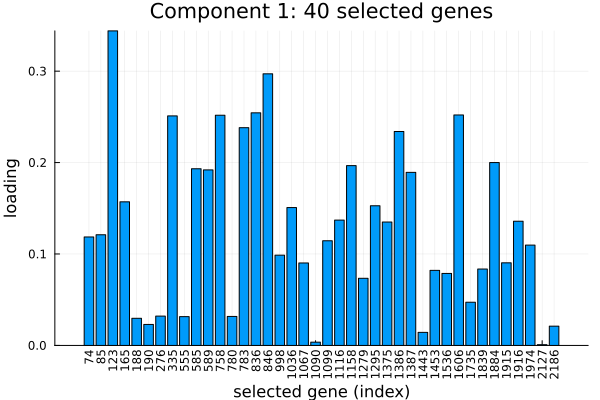

In [17]:
L1 = m.loadings_X[:, 1]
sel = findall(!iszero, L1)          # the 40 genes selected on component 1

bar(L1[sel]; xticks = (1:length(sel), string.(sel)), xrotation = 90,
    legend = false, xlabel = "selected gene (index)", ylabel = "loading",
    title = "Component 1: $(length(sel)) selected genes")



## Variable importance (VIP)

VIP (Variable Importance in Projection) summarizes each gene's contribution across all
components into a single score. We compute it as in `mixOmics`: variables with VIP above
$1$ are of above-average importance.

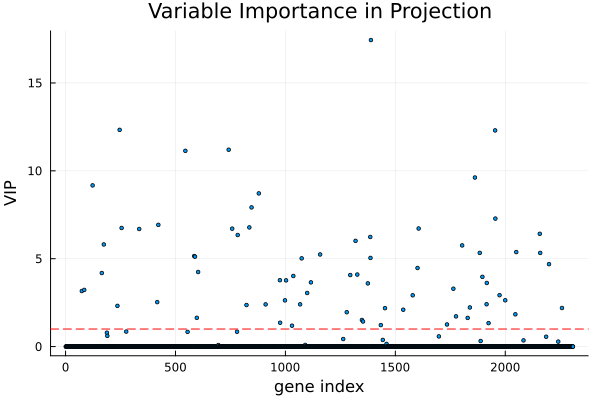

In [18]:
function vip(m)
    W = m.loadings_X
    H = m.ncomp
    Y = m.Y_dummy
    p = size(W, 1)
    VIP = zeros(p, H)
    cor2 = reshape(cor(Y, m.variates_X).^2, size(Y, 2), H)
    VIP[:, 1] .= W[:, 1].^2
    for h in 2:H
        Rd = vec(sum(cor2[:, 1:h], dims = 1))
        VIP[:, h] = (W[:, 1:h].^2 * Rd) ./ sum(Rd)
    end
    return sqrt.(p .* VIP)
end

vip_final = vip(m)[:, end]           # cross-component VIP

scatter(vip_final; markersize = 2, legend = false,
    xlabel = "gene index", ylabel = "VIP",
    title = "Variable Importance in Projection")
hline!([1.0], color = :red, linestyle = :dash)


Since the loadings are sparse in SPLSDA, most genes have VIP near $0$. The genes which are selected by
the model rise above the baseline. The ones above the dashed line at VIP = $1$ are the
most influential across the three components.

## Summary

In this example, we used a dataset with $63$ samples and $2308$ genes. The `splsda` model we fitted built three sparse components that separate the four tumor types while selecting only $40$, $9$, and $40$ genes. `splsda` can be used in any such dataset where the goal is discriminent analysis and the number of predictor variables exceeds the number of rows. 
